In [56]:
import os
import sys
import math
import random
import collections
import json
import time
import argparse
import numpy as np
import pandas as pd
import scipy.stats as sst
import scipy.io as sio
import sklearn.metrics as skm
import h5py
from tqdm import tqdm
import tqdm
import glob
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from torch.utils import data
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from torchvision.transforms import InterpolationMode
from torchvision.transforms import Compose, Resize, Normalize, ToTensor, CenterCrop
from torchvision.transforms.functional import InterpolationMode
from torchvision.datasets import ImageFolder
from torch.optim import lr_scheduler, SGD


from model.network import Net
from model.data import data_generate
from main import  eval

In [57]:
def plot_roc_multi_class(y_true, y_score, num_classes=4):
    """
    y_true: (N,) 真实标签 0~C-1
    y_score: (N, C) softmax概率
    return: 每一类AUC字典 + macro AUC
    """
    class_list=["AF", "Normal", "Others", "Noise"]
    # 1. 计算每一类 OvR ROC
    fpr_dict = dict()
    tpr_dict = dict()
    auc_dict = dict()

    for i in range(num_classes):
        # 把第i类作为正，其余全部负
        y_true_bin = (y_true == i).astype(int)
        y_pred_prob = y_score[:, i]
        fpr, tpr, _ = roc_curve(y_true_bin, y_pred_prob)
        fpr_dict[i] = fpr
        tpr_dict[i] = tpr
        auc_dict[i] = auc(fpr, tpr)

    # 2. macro AUC（所有类别AUC平均，sklearn内置）
    macro_auc = roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
    print(f"Macro AUC (OvR): {macro_auc:.4f}")
    for cls, auc_val in auc_dict.items():
        
        print(f"Class {class_list[cls]} AUC: {auc_val:.4f}")

    # 3. 绘图：绘制每一类ROC曲线
    plt.figure(figsize=(7,7))
    colors = plt.cm.get_cmap('tab10', num_classes).colors
    for i in range(num_classes):
        plt.plot(fpr_dict[i], tpr_dict[i], color=colors[i], lw=2,
                 label=f'Class {class_list[i]} (AUC={auc_dict[i]:.4f})')

    plt.plot([0,1], [0,1], 'k--', lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-class ROC (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.show()

    return auc_dict, macro_auc

def evaluation(model, device, params_dict, data_loader):
    model.eval()
    total_eval = 0
    correct_eval = 0.0
    with torch.no_grad():
        prob_list=[]
        label_list=[]
        for no_batch, (data, label) in enumerate(data_loader):
            data, label = data.to(device), label.to(device)
            score= model(data)#(bs, 35, 4)
            prob=F.softmax(score,dim=-1) #(bs, 35, 4)
            prob_ = prob.contiguous().view(-1, 4) #(N,4)
            label_=label.contiguous().view(-1)#(N)
            prob_=prob_.cpu().numpy()
            label_=label_.cpu().numpy()
            prob_list.append(prob_)
            label_list.append(label_)
        prob_ndarray=np.concatenate(prob_list, axis=0)
        label_ndarray=np.concatenate(label_list,axis=0)
    return prob_ndarray,label_ndarray
def load_pretrained_weights(model, pretrained_weights, checkpoint_key=None):
    if os.path.isfile(pretrained_weights):
        state_dict = torch.load(pretrained_weights, map_location="cpu")
        if checkpoint_key is not None and checkpoint_key in state_dict:
            print(f"Take key {checkpoint_key} in provided checkpoint dict")
            state_dict = state_dict[checkpoint_key]
        # remove `module.` prefix
        state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        msg = model.load_state_dict(state_dict, strict=False)
        print('Pretrained weights found at {} and loaded with msg: {}'.format(pretrained_weights, msg))
        return 1
    else:
        print("Pretrained weights is not found at {}".format(pretrained_weights))
        return 0

In [58]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_path = "./config/dev.json"
train_path = "./config/train.json"
params_dict = json.load(open("./config/modelconfig.json", 'r'))
model_path = os.path.join("./checkpoints/", "best_model.pth")
if os.path.isfile(model_path):
    print(f"model exists in {model_path}")
else:
    print("Path error!")

model exists in ../../../ExperimentResults/CinC2017\best_model_91.902.pth


In [59]:
model = Net(params_dict)
flag=load_pretrained_weights(model, model_path)
model=model.to(device)

Pretrained weights found at ../../../ExperimentResults/CinC2017\best_model_91.902.pth and loaded with msg: <All keys matched successfully>


100%|███████████████████████████████████████████████████████████████████████████████| 852/852 [00:00<00:00, 934.96it/s]


Macro AUC (OvR): 0.9405
Class AF AUC: 0.9489
Class Normal AUC: 0.9393
Class Others AUC: 0.9040
Class Noise AUC: 0.9700


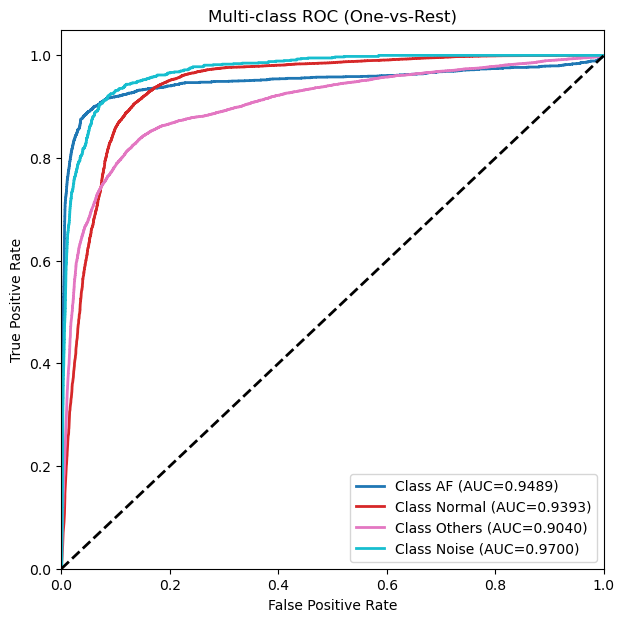

In [60]:
if flag==1:
    test_set, test_loader = data_generate(eval_path, params_dict, 1, drop_last=False)
    prob_ndarray,label_ndarray=evaluation(model,device, params_dict, test_loader)
    auc_per_class, macro_auc=plot_roc_multi_class(label_ndarray, prob_ndarray, num_classes=4)
